# Plot Tele-15 beam directions from ROS2 bag file

In [142]:
from pathlib import Path
from rosbags.highlevel import AnyReader  # this is actually a MARV library

from tf2_ros.buffer import Buffer
from geometry_msgs.msg import Transform, TransformStamped
from std_msgs.msg import Header
from rclpy.time import Time
from geometry_msgs.msg import Vector3, Quaternion
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd


class recording:
    def __init__(self, rosbag:str) -> None:
        """
        constructor
        """
        # members related to the AnyReader
        self._rosbag = Path(rosbag)
        self._ros_bag_paths = []
        self._ros_bag_names = []
        self._ros_reader = None
        self._ros_conns = None
        self._ros_topics = None
        self._ros_typestore = None

        self._scenario = None

        self._tf_buffer = Buffer()

        # helper members

        # execute processing steps
        self._getFilename()
        self._loadROSbag()  # load the rosbag, get all topic names
        self._plotBeamDirections()
        self._closeROSbag()  # close the AnyReader

    def _getFilename(self) -> None:
            """
            retrieves the file names from the self._ros_bag_dir user input.
            Note: Necessary, because only for ROS1 files the user will directly give the filename, for ROS2 they will provide the directory only.
            """
            if self._rosbag.exists():
                if self._rosbag.is_dir():  # user input is directory of ROS2 files (.db3 + metadata.yaml)
                    self._ros_bag_paths = list(self._rosbag.glob("*.db3")) # find the files
                    self._ros_bag_names = [path.stem for path in self._ros_bag_paths]
                elif self._rosbag.is_file() and self._rosbag.suffix == '.bag':  # user input is path of single ROS file (.bag)
                    self._ros_bag_paths = [self._rosbag]
                    self._ros_bag_names = [self._rosbag.stem]
            else:
                error_msg = f"Specified 'rosbag' path/dir is not existing!"
                print(error_msg)
                raise ValueError(error_msg)

    def _loadROSbag(self) -> None:
        """
        loads the ROS1 or ROS2 bagfile.
        Note: Directory or path of bagfile is given in costructor
        """
        self._ros_reader = AnyReader([self._rosbag])
        self._ros_reader.open()
        self._ros_typestore = self._ros_reader.typestore  # handles msg definitions
        # get all connections and all topics from the connections
        self._ros_conns = [conn for conn in self._ros_reader.connections]
        self._ros_topics = self._ros_reader.topics  #[conn.topic for conn in self._ros_conns]
        
        #print(f"Number of connections: {len(self._ros_conns)}")
        #print(f"The {len(self._ros_conns)} Topic Names are:")
        #for topic in self._ros_topics:
        #    print(f"- {topic}")
    
    def _closeROSbag(self) -> None:
        """
        ROS bag file opened with AnyReader must be explicitely closed.
        """
        self._ros_reader.close()

    def _processMsgsInROSbag(self, topic_name, func) -> None:

        # filter the connections for those we are interested in
        filtered_conns = self._filterConnections(self._ros_conns, topic_name)
        msgs = self._ros_reader.messages(connections=filtered_conns)

        for m, msg in enumerate(msgs):
            (connection, timestamp, rawdata) = msg
            if connection.topic == topic_name:
                # deserialize data 
                if m==7: # TODO: revert back. but for now we only want to look at the frames with the 
                    deserialized_msg = self._ros_typestore.deserialize_cdr(rawdata, connection.msgtype)
                    # call input function with deserialized data
                    func(deserialized_msg, m)
                    break # TODO remove this
                if m==20:
                    break

    def _filterConnections(self, connections, topic_names):
        """
        Filters the connections (from rosbags lib) by topic names listed in topic_names list
        """
        filtered_conns = []
        for conn in connections:
            if conn.topic in topic_names:
                #print(f"found {conn.topic} in {topic_names}")
                filtered_conns.append(conn)

        #print(f"Number of filtered connections: {len(filtered_conns)}")
        #for conn in filtered_conns:
            #print(f"- {conn}")
        return filtered_conns

    def _plotBeamDirections(self):

        topics = ["/livox/lidar_1PQDLCQ00139691"]
        for topic in topics:
            self._processMsgsInROSbag(topic_name=topic, func=self._readPointCloud)  # then read the TF tree info to get Lidar pose
    
    def _readPointCloud(self, msg, msg_idx) -> None:
        """
        reads point cloud and processes its contents
        """

        # check the definition of the pointFields array to know how the data is structured
        #print("\n   - Content of the PointFields array:")
        #print(*msg.fields, sep='\n')
        #print(f"type of the msg.data = {type(msg.data)}")
        #print(f"Stepsize between points in data according to width info: {len(msg.data)/msg.width}")

        calc_spherical = False

        if not calc_spherical:
            data = np.frombuffer(msg.data, dtype=np.uint8).reshape((-1, msg.point_step))
            x = np.frombuffer(np.ascontiguousarray(data[:, :4]), dtype=np.float32)
            y = np.frombuffer(np.ascontiguousarray(data[:, 4:8]), dtype=np.float32)
            z = np.frombuffer(np.ascontiguousarray(data[:, 8:12]), dtype=np.float32)
            time_offset = np.frombuffer(np.ascontiguousarray(data[:, 12:16]), dtype=np.uint32)
            az_rad = np.frombuffer(np.ascontiguousarray(data[:, 16:20]), dtype=np.float32)
            el_rad = np.frombuffer(np.ascontiguousarray(data[:, 20:24]), dtype=np.float32)
            range_m = np.frombuffer(np.ascontiguousarray(data[:, 24:28]), dtype=np.float32)
            reflectivity = np.frombuffer(np.ascontiguousarray(data[:, 28:32]), dtype=np.float32)
            tag = np.frombuffer(np.ascontiguousarray(data[:, 32:33]), dtype=np.uint8)
            line = np.frombuffer(np.ascontiguousarray(data[:, 33:34]), dtype=np.uint8)
            az_rad = np.where(az_rad > np.pi, az_rad - 2.0 * np.pi, az_rad)
            az_deg = np.rad2deg(az_rad)
            el_deg = np.rad2deg(el_rad)

            new_df = pd.DataFrame({ 'x': x,
                                    'y': y,
                                    'z': z,
                                    'time_offset': time_offset,
                                    'az_deg': az_deg,
                                    'el_deg': el_deg,
                                    'az_rad': az_rad,
                                    'el_rad': el_rad,
                                    'range_m': range_m,
                                    'reflectivity': reflectivity,
                                    'tag': tag,
                                    'line': line})

            # analyse the weird 576 invalid points without any directions every 10th frame
            new_df['time_step'] = new_df['time_offset'].diff()
            invalid_points_df = new_df[new_df['el_deg']==90.0]
            print(f"tag info of the invalid points: \n{invalid_points_df['tag'].value_counts()}")
            # --> seems as if the tag is always equal to 0
            print(f"line numbers of the invalid points: \n{invalid_points_df['line'].value_counts()}")
            # --> seems as if there are equal amounts for every laser/line, that is 96.
            print(f"range_m of the invalid points: \n{invalid_points_df['range_m'].value_counts()}")
            print(f"time_offset of the invalid points: \n{invalid_points_df['time_offset'].describe()}")
            # inspecting the time_offset a little bit further:
            max = invalid_points_df['time_offset'].max()
            min = invalid_points_df['time_offset'].min()
            diff = max - min
            n_invalid_pts = len(invalid_points_df)
            avg_time_step = diff / n_invalid_pts
            print(f"the maximum of the time_offset of the invalid points is: max={max}")
            print(f"the minimum of the time_offset of the invalid points is: min={min}")
            print(f"the diff of min-max the time_offset of the invalid points is: diff={diff}")
            print(f"the number of invalid points is: n_invalid_pts={n_invalid_pts}")
            print(f"the average time step between the invalid points is: avg_time_step={avg_time_step}")
            print(f"time_steps of the invalid points: \n{invalid_points_df['time_step'].value_counts()}")

            print(f"Conclusion: The 576 invalid points are evenly distributed across the 6 lasers: 96 each. \
                  \n They consist of equal numbers of first and second returns, because the time_step is either 0ns or 4167.0ns. \
                  \n However, the first and second returns cannot be differentiated by their tag, because the tag is always = 0 for these invalid points. \
                  \n ")
            
            # check out the problematic area of the invalid points. where are the exatly located?
            new_df['location_of_invalid_pts'] = np.where(time_offset<min,1,0) + np.where(time_offset>min,2,0) + np.where(time_offset>max,3,0)
            min_idx = new_df.index[new_df['time_offset'] == min].min()  # the min_idx would be a list of two indices bec. the time_offset is the same for the two returns
            max_idx = new_df.index[new_df['time_offset'] == max].max()
            print(f"min index = {min_idx.astype(int)}")
            min_df = new_df.loc[min_idx-120:min_idx-1]
            max_df = new_df.loc[max_idx+1:max_idx+120]
            invalids_by_idx_df = new_df.loc[min_idx:max_idx]
            edges_df = new_df.loc[[min_idx, max_idx]]

            # for comparsion the average time step between all points in the point cloud:
            max_ = new_df['time_offset'].max()
            min_ = new_df['time_offset'].min()
            diff_ = max - min
            n_all_pts = len(new_df)
            avg_time_step_ = diff / n_all_pts
            print("***************")
            print(f"the maximum of the time_offset of ALL points is: max={max_}")
            print(f"the minimum of the time_offset of ALL points is: min={min_}")
            print(f"the diff of min-max the time_offset of ALL points is: diff={diff_}")
            print(f"the number of ALL points is: n_invalid_pts={n_all_pts}")
            print(f"the average time step between ALL points is: avg_time_step={avg_time_step_}")
            print(f"time_steps of ALL points: \n{new_df['time_step'].value_counts()}")

            # for comparison how the tag info looks like for valid no-hit points. 
            print(f"tag info of range_m = 0 points: \n{new_df[new_df['range_m']==0.0]['tag'].value_counts()}")
            # for comparison how the tag info looks like for valid hit points. 
            print(f"tag info of range_m > 0 points: \n{new_df[new_df['range_m']>0.0]['tag'].value_counts()}")
            # for comparison how the tag info looks like for all points. 
            print(f"tag info of ALL points: \n{new_df['tag'].value_counts()}")

            # calculate No-Hit Flag:
            new_df["No-Hit"] = new_df["range_m"]==0.0

            print(f"Frame {msg_idx} Count of 90° values: {new_df['el_deg'].value_counts().get(90.0,0)}")
            #print(new_df.info())
            #print(new_df.describe())
            #print(new_df)

            ax = new_df.plot.scatter(x="az_deg", y="el_deg", c="time_offset", s=1, figsize=(15,5))
            ax.set_aspect('equal')
            ax.set_title(f"Real Scanning Pattern of Livox Tele-15 Frame {msg_idx}")
            ax.set_ylabel("Elevation [deg]")
            ax.set_xlabel("Azimuth [deg]")
            #ax.set_xlim(-10,10)
            #ax.set_ylim(80,100)
            ax.set_ylim(-2.5,2.5)
            ax.set_xlim(-10,5)
            min_df.plot.scatter(x="az_deg", y="el_deg", c="b", s=1, figsize=(15,5), ax=ax)
            max_df.plot.scatter(x="az_deg", y="el_deg", c="r", s=1, figsize=(15,5), ax=ax)
            #invalids_by_idx_df.plot.scatter(x="az_deg", y="el_deg", c="g", s=2, figsize=(15,5), ax=ax)
            edges_df.plot.scatter(x="az_deg", y="el_deg", c="g", s=4, figsize=(15,5), ax=ax)
            #plt.savefig(f'Livox_Tele-15_pattern_frame{msg_ids}.png')
            #plt.show()
            #plt.close()
            ax1 = new_df.plot.scatter(x="az_deg", y="el_deg", c="time_offset", s=1, figsize=(15,5))
            ax1.set_aspect('equal')
            ax1.set_title(f"Real Scanning Pattern of Livox Tele-15 Frame {msg_idx}")
            ax1.set_ylabel("Elevation [deg]")
            ax1.set_xlabel("Azimuth [deg]")
            ax1.set_xlim(-1,1)
            ax1.set_ylim(89,91)
            #ax1.set_ylim(-2.5,2.5)
            #ax1.set_xlim(-10,5)
            min_df.plot.scatter(x="az_deg", y="el_deg", c="b", s=1, figsize=(15,5), ax=ax1)
            max_df.plot.scatter(x="az_deg", y="el_deg", c="r", s=1, figsize=(15,5), ax=ax1)
            #invalids_by_idx_df.plot.scatter(x="az_deg", y="el_deg", c="g", s=2, figsize=(15,5), ax=ax1)
            edges_df.plot.scatter(x="az_deg", y="el_deg", c="g", s=4, figsize=(15,5), ax=ax1)


            ax2 = new_df.plot.scatter(x="time_offset", y="line", c="time_offset", s=1, figsize=(15,5))
            ax2.set_title(f"Real Scanning Pattern of Livox Tele-15 Frame {msg_idx}")
            ax2.set_ylabel("line")
            ax2.set_xlabel("time_offset [ns]")
            ax2.set_xlim(new_df.loc[min_idx-500]['time_offset'], new_df.loc[max_idx+500]['time_offset'])
            ax2.set_ylim(-1,6)
            min_df.plot.scatter(x="time_offset", y="line", c="b", s=1, figsize=(15,5), ax=ax2)
            max_df.plot.scatter(x="time_offset", y="line", c="r", s=1, figsize=(15,5), ax=ax2)
            invalids_by_idx_df.plot.scatter(x="time_offset", y="line", c="k", s=4, figsize=(15,5), ax=ax2)
            edges_df.plot.scatter(x="time_offset", y="line", c="g", s=4, figsize=(15,5), ax=ax2)
        else: # this is just for visualization of the old pointcloud content without spherical coordinate information.
            data = np.frombuffer(msg.data, dtype=np.uint8).reshape((-1, msg.point_step))
            x = np.frombuffer(np.ascontiguousarray(data[:, :4]), dtype=np.float32)
            y = np.frombuffer(np.ascontiguousarray(data[:, 4:8]), dtype=np.float32)
            z = np.frombuffer(np.ascontiguousarray(data[:, 8:12]), dtype=np.float32)
            reflectivity = np.frombuffer(np.ascontiguousarray(data[:, 12:16]), dtype=np.float32)
            tag = np.frombuffer(np.ascontiguousarray(data[:, 16:17]), dtype=np.uint8)
            line = np.frombuffer(np.ascontiguousarray(data[:, 17:18]), dtype=np.uint8)
            range_m = np.sqrt(x**2+y**2+z**2)
            el_rad = np.where(range_m != 0.0, np.arcsin(z/range_m), 0.0)
            az_rad = np.where(x!=0, np.arctan2(y,x), 0.0)
            az_rad = np.where(az_rad > np.pi, az_rad - 2.0 * np.pi, az_rad)
            az_deg = np.rad2deg(az_rad)
            el_deg = np.rad2deg(el_rad)

            new_df = pd.DataFrame({ 'x': x,
                                    'y': y,
                                    'z': z,
                                    'az_deg': az_deg,
                                    'el_deg': el_deg,
                                    'az_rad': az_rad,
                                    'el_rad': el_rad,
                                    'range_m': range_m,
                                    'reflectivity': reflectivity,
                                    'tag': tag,
                                    'line': line})


            # calculate No-Hit Flag:
            new_df["No-Hit"] = new_df["range_m"]==0.0

            print(f"Frame {msg_idx} Count of 90° values: {new_df['el_deg'].value_counts().get(90.0,0)}")
            #print(new_df.info())
            #print(new_df.describe())
            #print(new_df)

            ax = new_df.plot.scatter(x="az_deg", y="el_deg", c="range_m", s=1, figsize=(15,5))
            ax.set_aspect('equal')
            ax.set_title(f"Real Scanning Pattern of Livox Tele-15 Frame {msg_idx}")
            ax.set_ylabel("Elevation [deg]")
            ax.set_xlabel("Azimuth [deg]")
            #ax.set_xlim(-10,10)
            #ax.set_ylim(-10,10)
            #plt.savefig(f'Livox_Tele-15_pattern_frame{msg_ids}.png')
            #plt.show()
            #plt.close()
        

Processing real recording '/home/markus/Development/sim_poc_nvidia_omniverse/ws_tele15_ROS2/rosbag2_2025_07_18-22_43_28//'
tag info of the invalid points: 
tag
0    576
Name: count, dtype: int64
line numbers of the invalid points: 
line
0    96
1    96
2    96
3    96
4    96
5    96
Name: count, dtype: int64
range_m of the invalid points: 
range_m
0.0    576
Name: count, dtype: int64
time_offset of the invalid points: 
count    5.760000e+02
mean     6.070190e+07
std      3.467369e+05
min      6.010394e+07
25%      6.040292e+07
50%      6.070190e+07
75%      6.100088e+07
max      6.129986e+07
Name: time_offset, dtype: float64
the maximum of the time_offset of the invalid points is: max=61299865
the minimum of the time_offset of the invalid points is: min=60103936
the diff of min-max the time_offset of the invalid points is: diff=1195929
the number of invalid points is: n_invalid_pts=576
the average time step between the invalid points is: avg_time_step=2076.265625
time_steps of the inv

/tmp/ipykernel_18822/3545703903.py:63: DeprecationWarning: AnyReader should be instantiated with an explicit typestore when reading old Rosbag2 files without embedded message type definions. Using `foxy` types as a workaround.
  self._ros_reader.open()
/home/markus/.local/lib/python3.8/site-packages/pandas/plotting/_matplotlib/core.py:1258: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(
/home/markus/.local/lib/python3.8/site-packages/pandas/plotting/_matplotlib/core.py:1258: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(
/home/markus/.local/lib/python3.8/site-packages/pandas/plotting/_matplotlib/core.py:1258: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


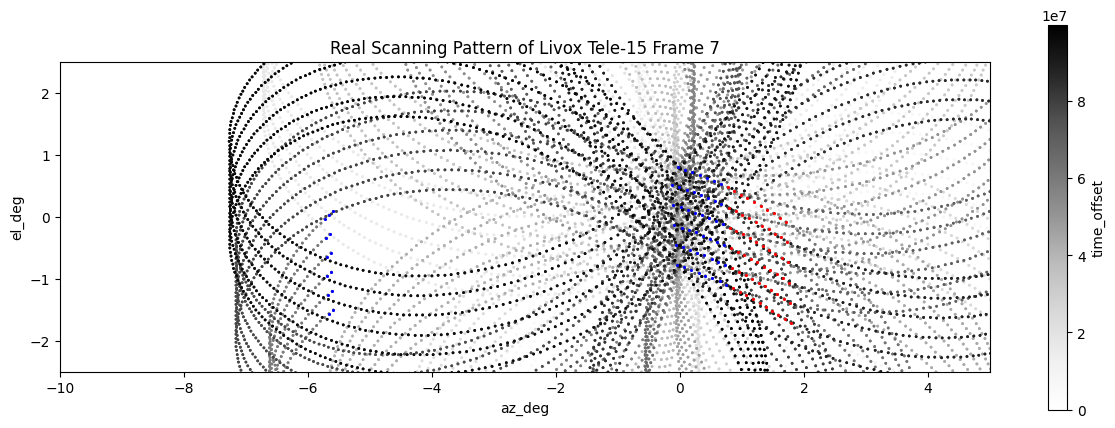

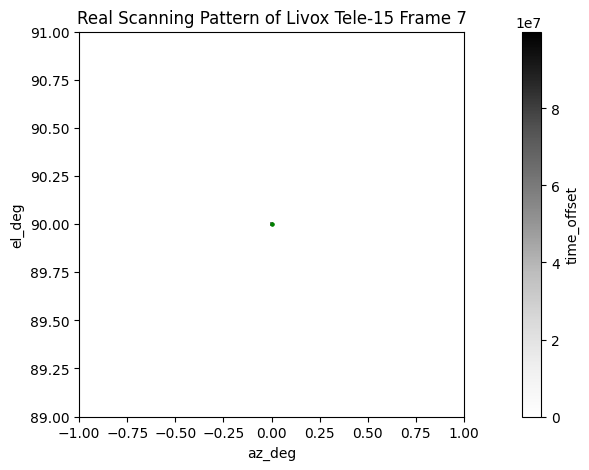

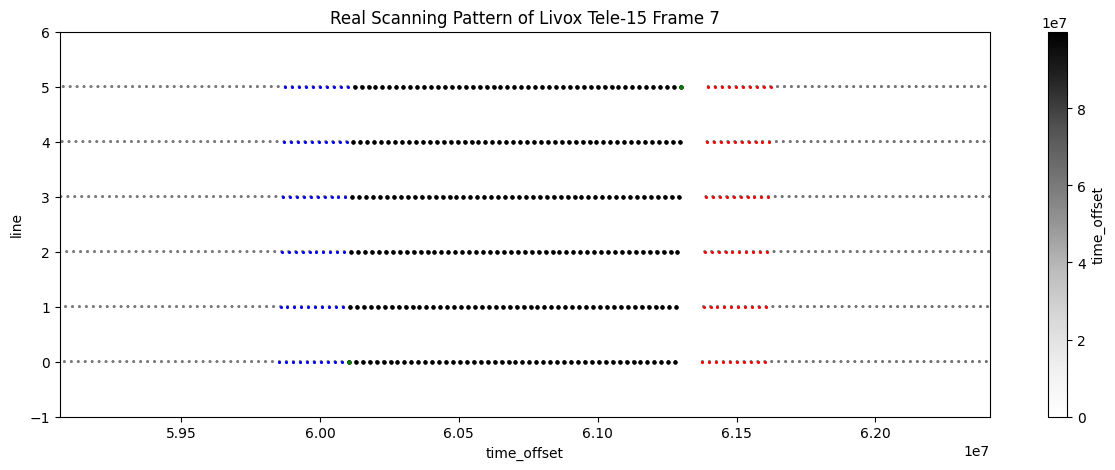

In [143]:
################################################# Start Scenario Evaluation #################################################

# conditions for specifying input ros file paths:
# 1. to open ROS1 bagfiles we must give the complete path+name of the .bag file.
# 2. to open ROS2 bagfiles we must give the path of the folder containing the .db3 or .mcap files. Because it looks for the .metadata.yaml file in that directory to decide whether to use a ROS1 or ROS2 reader.

## 1. Analyse real recording

bag_file = "/mnt/dbs-omniverse-dev/markusfranzziegler/rosbags/Livox_Tele-15/HVLE-2024-06-14/rain_rate_min_det_range_target_1_2024-06-14-11-05-31.bag"
#realROS1Recording = recording(rosbag=bag_file)

db3_folder = "/home/markus/Development/sim_poc_nvidia_omniverse/ws_tele15_ROS2/rosbag2_2025_07_18-22_43_28//"  # tele-15 recording of my speakers in the livingroom
mcap_folder = ""  # example for bagfile with mutliple lidars in it. could be used for a test.
print(f"Processing real recording '{db3_folder}'")
realROS2Recording = recording(rosbag=db3_folder)